# Phase 2 — QC filtering & cohort construction

Turns `data/interim/samples_harmonized.parquet` (Phase 1's output) into an auditable,
filtered working set and the three cohorts IMPLEMENTATION.md's Phase 5 needs. The
logic lives in `src/cohorts.py`; this notebook runs it once end to end, writes
`data/processed/cohort_{labeled_all,within_project,healthy_baseline}.parquet`,
`reports/cohort_flow.md` and `reports/project_summary.csv`.

Every exclusion is logged with a before/after count, and no cohort's membership is
ever read off `projects.csv.condition` -- membership comes only from `disease_label`,
which Phase 1 built from per-sample values curated in `config/within_study_review.csv`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import cohorts as coh

REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)

with open(ROOT / "config" / "params.yaml") as f:
    params = yaml.safe_load(f)
review_df = pd.read_csv(ROOT / "config" / "within_study_review.csv")

print(f"depth_threshold: {params['qc']['depth_threshold']:,}")
print(f"min_cases_per_project / min_controls_per_project: "
      f"{params['qc']['min_cases_per_project']} / {params['qc']['min_controls_per_project']}")
print(f"review_df buckets: {review_df['bucket'].value_counts().to_dict()}")

depth_threshold: 10,000
min_cases_per_project / min_controls_per_project: 10 / 10
review_df buckets: {'CONFIRMED': 53, 'HEALTHY_ONLY': 9, 'COLONISATION': 5, 'NEEDS_CHECK': 3, 'FALSE_POSITIVE': 2}


## Load Phase 0 / Phase 1 outputs

In [2]:
harmonized = pd.read_parquet(ROOT / "data" / "interim" / "samples_harmonized.parquet")
sample_depth = pd.read_parquet(ROOT / "data" / "interim" / "sample_depth.parquet")

print("harmonized:", harmonized.shape)
print("sample_depth:", sample_depth.shape)
assert len(harmonized) == 168_464
assert set(harmonized["srr"]).issubset(set((sample_depth["sample"].str.split("_").str[-1])))

harmonized: (168464, 91)
sample_depth: (168464, 3)


## Step 1 — QC exclusions (fixed order)

1. **Non-human `host_species`** — only samples *positively* identified as non-human
   are dropped. The `<NA>` bucket (no host tag at all, or free text naming neither) is
   kept: absence of evidence isn't evidence of non-human, and Phase 1 already flagged
   this as "needs review, not a pass" rather than something to silently guess either
   way.
2. **Non-stool `sample_type`** — kept only when the project-level value is exactly
   `"stool"`. Every mixed-body-site combination and every missing value is dropped.
3. **Depth below the threshold** — joined from `sample_depth.parquet` on the
   `{project}_{srr}` key Phase 0 used, not `sample_metadata.total_bases` (missing for
   1.58% of samples and measures bases submitted, not reads assigned).

In [3]:
qc_df, flow = coh.apply_qc_filters(harmonized, sample_depth, params["qc"]["depth_threshold"])

for f in flow:
    print(f"{f['step']:45s} {f['n_in']:>7,} -> {f['n_out']:>7,}  (-{f['n_removed']:,})")
    print(f"  {f['note']}")

assert flow[0]["n_in"] - sum(f["n_removed"] for f in flow) == len(qc_df)
print(f"\nPASS — flow arithmetic reconciles: {flow[0]['n_in']:,} - "
      f"{sum(f['n_removed'] for f in flow):,} removed = {len(qc_df):,}")

exclude confirmed non-human host_species      168,464 -> 167,961  (-503)
  46,005 samples with unresolved host_species (<NA>) kept, not dropped
exclude non-stool / missing sample_type       167,961 -> 127,161  (-40,800)
  kept only sample_type == "stool" exactly; mixed body sites and missing values dropped
exclude depth < 10,000 reads                  127,161 -> 116,657  (-10,504)
  depth = row sum from sample_depth.parquet (Phase 0), not sample_metadata.total_bases

PASS — flow arithmetic reconciles: 168,464 - 51,807 removed = 116,657


## Step 2 — Depth-threshold justification (empirical, not true rarefaction)

Phase 0 already computed each sample's depth and non-zero-taxon count -- no per-sample
subsampling simulation exists yet. This plots the *empirical* depth-vs-richness
relationship (mean richness per log-spaced depth bin) as a proxy for a rarefaction
curve, to show roughly where richness growth slows. It is **not** a substitute for
Phase 6's proper sensitivity analysis at 5,000 / 10,000 / 20,000 reads, which this
plot only motivates the default for.

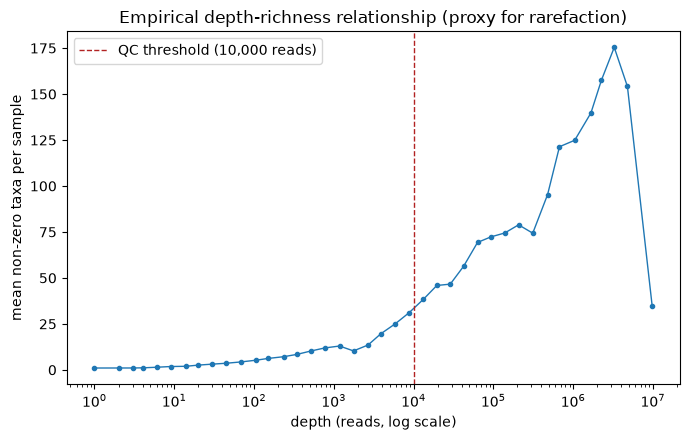

mean richness below threshold: 8.0 (n_bins=23); above: 91.8 (n_bins=17)
Richness is still rising past 10,000 reads (this is compositional 16S data, not a hard-saturating curve), but the STEEPEST gains are below it -- consistent with 10,000 as a floor that excludes the clearly-undersampled tail, not a claim that richness is fully saturated there. See Phase 6 for the formal threshold sensitivity check.


In [4]:
curve = coh.depth_richness_curve(sample_depth)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(curve["depth_mid"], curve["richness_mean"], marker="o", ms=3, lw=1)
ax.set_xscale("log")
ax.axvline(params["qc"]["depth_threshold"], color="firebrick", ls="--", lw=1,
           label=f"QC threshold ({params['qc']['depth_threshold']:,} reads)")
ax.set_xlabel("depth (reads, log scale)")
ax.set_ylabel("mean non-zero taxa per sample")
ax.set_title("Empirical depth-richness relationship (proxy for rarefaction)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "depth_richness_empirical.png", dpi=150)
plt.show()

below = curve[curve["depth_mid"] < params["qc"]["depth_threshold"]]
above = curve[curve["depth_mid"] >= params["qc"]["depth_threshold"]]
print(f"mean richness below threshold: {below['richness_mean'].mean():.1f} "
      f"(n_bins={len(below)}); above: {above['richness_mean'].mean():.1f} (n_bins={len(above)})")
print("Richness is still rising past 10,000 reads (this is compositional 16S data, "
      "not a hard-saturating curve), but the STEEPEST gains are below it -- consistent "
      "with 10,000 as a floor that excludes the clearly-undersampled tail, not a claim "
      "that richness is fully saturated there. See Phase 6 for the formal threshold "
      "sensitivity check.")

## Step 3 — `within_project` cohort (Way A)

QC-passed samples in the 53 CONFIRMED projects, each project then required to still
clear >= 10 cases and >= 10 controls (`config/params.yaml`) — QC can push a project
below the curation-time threshold. Failing projects are dropped and listed here, not
silently kept under-powered.

In [5]:
within_project, excluded_wp = coh.build_within_project_cohort(
    qc_df, review_df, params["qc"]["min_cases_per_project"], params["qc"]["min_controls_per_project"],
)

print(f"within_project: {len(within_project):,} samples across {within_project['project'].nunique()} projects "
      f"(of 53 CONFIRMED)")
print(f"\n{len(excluded_wp)} projects excluded (fell below 10/10 after QC, all shown -- 0/0 means every "
      f"sample in that project was removed by QC, typically because its sample_type isn't exactly \"stool\"):")
print(excluded_wp.to_string(index=False))

within_project: 14,033 samples across 41 projects (of 53 CONFIRMED)

12 projects excluded (fell below 10/10 after QC, all shown -- 0/0 means every sample in that project was removed by QC, typically because its sample_type isn't exactly "stool"):
    project  n_controls  n_cases
  PRJEB5729           0        0
PRJNA227062           0        0
PRJNA280026           0        0
PRJNA317429           0        0
PRJNA350277           0        0
PRJNA401981           0        0
PRJNA529598           0        0
PRJNA641414           0        0
PRJNA685403           0        0
PRJNA704289           0        0
PRJNA736821           0        0
PRJNA760529           0        0


## Step 4 — `labeled_all` cohort (Way B, current label coverage)

Every QC-passed sample with a non-null `disease_label` — the 62 curated projects
(53 CONFIRMED + 9 HEALTHY_ONLY) from Phase 1, not yet the full 116-project catalogue
IMPLEMENTATION.md specifies. See `notebooks/01_harmonize.ipynb`'s closing notes for
why that gap is flagged rather than approximated.

In [6]:
labeled_all = coh.build_labeled_all_cohort(qc_df)
print(f"labeled_all: {len(labeled_all):,} samples across {labeled_all['project'].nunique()} projects")
print(labeled_all["disease_label"].value_counts().rename("count").to_string())

assert set(within_project["srr"]).issubset(set(labeled_all["srr"])), "within_project must be a subset of labeled_all"
print("\nPASS — within_project is a subset of labeled_all")

labeled_all: 14,954 samples across 48 projects
disease_label
healthy    9285
case       5669

PASS — within_project is a subset of labeled_all


## Step 5 — `healthy_baseline` cohort

QC-passed samples labelled `healthy` in projects with **zero** `case`-labelled
samples — computed from `disease_label` directly. With current label coverage this
reduces to (a subset of) the 9 HEALTHY_ONLY projects, since every CONFIRMED project
has both labels by construction, but the computation itself doesn't hardcode that.

In [7]:
healthy_baseline = coh.build_healthy_baseline_cohort(qc_df)
print(f"healthy_baseline: {len(healthy_baseline):,} samples across {healthy_baseline['project'].nunique()} projects")
print(healthy_baseline.groupby("project").size().rename("n_samples").to_string())

overlap = set(healthy_baseline["srr"]) & set(labeled_all.loc[labeled_all["disease_label"] == "case", "srr"])
assert not overlap, f"healthy_baseline must not overlap any case sample: {overlap}"
print("\nPASS — healthy_baseline is disjoint from labeled_all's case samples")

healthy_baseline: 921 samples across 7 projects
project
PRJEB5714       48
PRJNA388263    419
PRJNA398279    121
PRJNA495320    153
PRJNA540406     49
PRJNA550519     76
PRJNA622517     55

PASS — healthy_baseline is disjoint from labeled_all's case samples


## Step 6 — Structural check: no cohort depends on `projects.csv.condition`

Not a data assertion (the column isn't even loaded here) — a code-level guarantee.
`coh.apply_qc_filters` / `build_within_project_cohort` / `build_labeled_all_cohort` /
`build_healthy_baseline_cohort` in `src/cohorts.py` reference `host_species_human`,
`sample_type`, `depth` and `disease_label` only; `condition`/`condition_category`
never appears in any cohort-membership decision, only in `project_summary` below for
reporting.

In [8]:
import ast
import inspect

funcs = [coh.apply_qc_filters, coh.build_within_project_cohort,
         coh.build_labeled_all_cohort, coh.build_healthy_baseline_cohort]
for fn in funcs:
    tree = ast.parse(inspect.getsource(fn))
    columns_accessed = {
        n.value for n in ast.walk(tree)
        if isinstance(n, ast.Constant) and isinstance(n.value, str)
    }
    assert not {"condition", "condition_category"} & columns_accessed, \
        f"{fn.__name__} references a condition column: {columns_accessed & {'condition', 'condition_category'}}"
print("PASS — no cohort-membership function's code (docstrings excluded) references "
      "`condition` / `condition_category` as a column")

PASS — no cohort-membership function's code (docstrings excluded) references `condition` / `condition_category` as a column


## Step 7 — Per-project summary

In [9]:
project_summary = coh.project_summary(qc_df)
project_summary.to_csv(REPORTS / "project_summary.csv", index=False)

print(f"{len(project_summary)} projects in the QC-passed population")
print(project_summary.sort_values("n_cases", ascending=False).head(10).to_string(index=False))

341 projects in the QC-passed population
    project  n_samples amplicon           kit_family     instrument                           region  n_controls  n_cases
PRJNA729511       3712       v4               Qiagen         454 GS      Europe and Northern America         866     1409
PRJNA601994        725       v4               Qiagen Illumina MiSeq      Europe and Northern America         263      462
PRJNA290926        478       v4               Qiagen         454 GS      Europe and Northern America         120      308
PRJNA413199        446       v4 other_or_unspecified Illumina MiSeq      Europe and Northern America          70      251
PRJNA307231        292    v3-v4 other_or_unspecified Illumina MiSeq      Europe and Northern America          44      248
PRJNA318004        355       v4               Qiagen Illumina MiSeq      Europe and Northern America          79      238
PRJNA648321        416    v3-v4 other_or_unspecified Illumina MiSeq      Europe and Northern America     

## Step 8 — Write cohorts and flow report

In [10]:
for name, cohort in [("labeled_all", labeled_all), ("within_project", within_project),
                      ("healthy_baseline", healthy_baseline)]:
    out_path = ROOT / "data" / "processed" / f"cohort_{name}.parquet"
    cohort.to_parquet(out_path, index=False)
    print(f"wrote {out_path.relative_to(ROOT)}: {cohort.shape}")

cohort_sizes = {
    "labeled_all": (len(labeled_all), labeled_all["project"].nunique()),
    "within_project": (len(within_project), within_project["project"].nunique()),
    "healthy_baseline": (len(healthy_baseline), healthy_baseline["project"].nunique()),
}
flow_md = coh.flow_report_md(flow, cohort_sizes)
(REPORTS / "cohort_flow.md").write_text(flow_md + "\n", encoding="utf-8")
print()
print(flow_md)

wrote data\processed\cohort_labeled_all.parquet: (14954, 92)


wrote data\processed\cohort_within_project.parquet: (14033, 92)
wrote data\processed\cohort_healthy_baseline.parquet: (921, 92)

# Phase 2 cohort flow

## QC exclusions (fixed order)

| step | n in | n removed | n out | note |
|---|---|---|---|---|
| exclude confirmed non-human host_species | 168,464 | 503 | 167,961 | 46,005 samples with unresolved host_species (<NA>) kept, not dropped |
| exclude non-stool / missing sample_type | 167,961 | 40,800 | 127,161 | kept only sample_type == "stool" exactly; mixed body sites and missing values dropped |
| exclude depth < 10,000 reads | 127,161 | 10,504 | 116,657 | depth = row sum from sample_depth.parquet (Phase 0), not sample_metadata.total_bases |

## Cohorts (built from the QC-passed population)

| cohort | n samples | n projects |
|---|---|---|
| labeled_all | 14,954 | 48 |
| within_project | 14,033 | 41 |
| healthy_baseline | 921 | 7 |


## Summary

In [11]:
for f in sorted((ROOT / "data" / "processed").glob("*")) + sorted(REPORTS.glob("*.md")) + \
        sorted(REPORTS.glob("*.csv")) + sorted(FIGURES.glob("*")):
    print(f"{str(f.relative_to(ROOT)):45s} {f.stat().st_size / 1e6:8.3f} MB")

data\processed\cohort_healthy_baseline.parquet    0.088 MB
data\processed\cohort_labeled_all.parquet        0.631 MB
data\processed\cohort_within_project.parquet     0.595 MB
reports\cohort_flow.md                           0.001 MB
reports\harmonization_coverage.md                0.001 MB
reports\project_summary.csv                      0.026 MB
reports\figures\depth_richness_empirical.png     0.060 MB


## Results and methodological notes

### What this notebook produced

`data/processed/cohort_{labeled_all,within_project,healthy_baseline}.parquet`,
`reports/cohort_flow.md` (the CONSORT-style exclusion accounting) and
`reports/project_summary.csv` (per-project n/cases/controls/amplicon/kit/instrument/
region, for deciding which projects enter Phase 5's meta-analysis).

### QC removes more of the curated disease cohort than expected -- and that's real

168,464 -> 116,657 samples survive QC (503 confirmed non-human, 40,800 non-stool,
10,504 low-depth). Applied to the 53 CONFIRMED within-study projects, this drops 12 of
them to zero surviving samples: `PRJEB5729`, `PRJNA227062`, `PRJNA280026`,
`PRJNA317429`, `PRJNA350277`, `PRJNA401981`, `PRJNA529598`, `PRJNA641414`,
`PRJNA685403`, `PRJNA704289`, `PRJNA736821`, `PRJNA760529` -- all confirmed by
inspection to have a genuinely non-stool `sample_type` (`"oral swab, stool, skin
swab"`, `"rectal swabs, fecal aspirate and biopsies"`, `"gut mucosal samples"`, etc.),
not a QC bug. **`within_project` is therefore 41 projects / 14,033 samples, not 53 /
~18,541** -- a real, load-bearing finding for Phase 5, not a rounding difference. The
excluded-projects table in Step 3 lists all 12 by name so this is auditable rather
than a silent shrinkage.

### `labeled_all` is 48 projects, not 116

Same scope note as Phase 1: `disease_label` currently covers 62 curated projects (53
CONFIRMED + 9 HEALTHY_ONLY), of which 48 have at least one sample surviving QC.
Reaching the full 116-project / ~31,239-sample Way B cohort needs the remaining ~63
candidate fields in `audit/health_field_catalogue.csv` triaged into
`within_study_review.csv` the same way -- not new Phase 2 work, a Phase 1 curation
extension.

### `healthy_baseline` is small and deliberately conservative

921 samples across 7 of the 9 HEALTHY_ONLY projects (2 lost entirely to QC, same
non-stool pattern as above). This is far smaller than ANALYSIS_PLAN.md's original
~54,571/125 estimate from `projects.csv.condition == "healthy"` -- expected and
correct, since that estimate is known to include contaminated "healthy" studies that
actually contain cases (PRJEB11419, PRJEB5729, PRJNA554232, all three already living
in `within_project` instead). A larger `healthy_baseline` is available only by
curating more of the 121 `condition == "healthy"` candidate projects the same
rigorous way (112 of 121 had no per-sample field that cleared the all-values-control
bar in Phase 1's scan and were excluded, not guessed in).

### For Phase 3

`data/processed/cohort_within_project.parquet` and `cohort_healthy_baseline.parquet`
are the two cohorts Phase 5's differential-abundance work needs; `cohort_labeled_all.parquet`
is Way B at current label coverage. All three already have `age_years`, `sex`, `bmi`,
`disease_label`/`disease_category`, and the technical covariates (`amplicon`,
`kit_family`, `instrument`, `region`, `depth`) joined in -- Phase 3's normalisation
step can read these parquet files directly, no further joining needed.